In [1]:
import numpy as np
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
iris=datasets.load_iris()
X=iris.data

In [3]:
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X)
print("Explained variance ratio:",pca)

Explained variance ratio: PCA(n_components=2)


In [5]:
X_pca

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451],
       [-2.28085963,  0.74133045],
       [-2.82053775, -0.08946138],
       [-2.62614497,  0.16338496],
       [-2.88638273, -0.57831175],
       [-2.6727558 , -0.11377425],
       [-2.50694709,  0.6450689 ],
       [-2.61275523,  0.01472994],
       [-2.78610927, -0.235112  ],
       [-3.22380374, -0.51139459],
       [-2.64475039,  1.17876464],
       [-2.38603903,  1.33806233],
       [-2.62352788,  0.81067951],
       [-2.64829671,  0.31184914],
       [-2.19982032,  0.87283904],
       [-2.5879864 ,  0.51356031],
       [-2.31025622,  0.39134594],
       [-2.54370523,  0.43299606],
       [-3.21593942,  0.13346807],
       [-2.30273318,  0.09870885],
       [-2.35575405, -0.03728186],
       [-2.50666891, -0.14601688],
       [-2.46882007,  0.13095149],
       [-2.56231991,  0.36771886],
       [-2.63953472,

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

iris=datasets.load_iris()
X=iris.data[:,:] #  1:100 ,1:3
y=iris.target
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X)



In [38]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

In [46]:
models=[
    ("Linear Kernal",SVC(kernel='linear',C=1)),
    ("RBF Kernal(gamma=0.5)",SVC(kernel='rbf',C=1,gamma=0.5)),
    ("RBF Kernal(gamma=5)",SVC(kernel='rbf',C=1,gamma=5)),
     ("Polynomial Kernal(degree=3)",SVC(kernel='rbf',C=1,degree=3))
]

In [47]:
h=0.02
x_min,x_max=X_pca[:,0].min()-1,X_pca[:,0].max()+1
y_min,y_max=X_pca[:,1].min()-1,X_pca[:,1].max()+1
xx,yy=np.meshgrid(np.arange(x_min,x_max,h),
                  np.arange(y_min,y_max,h))

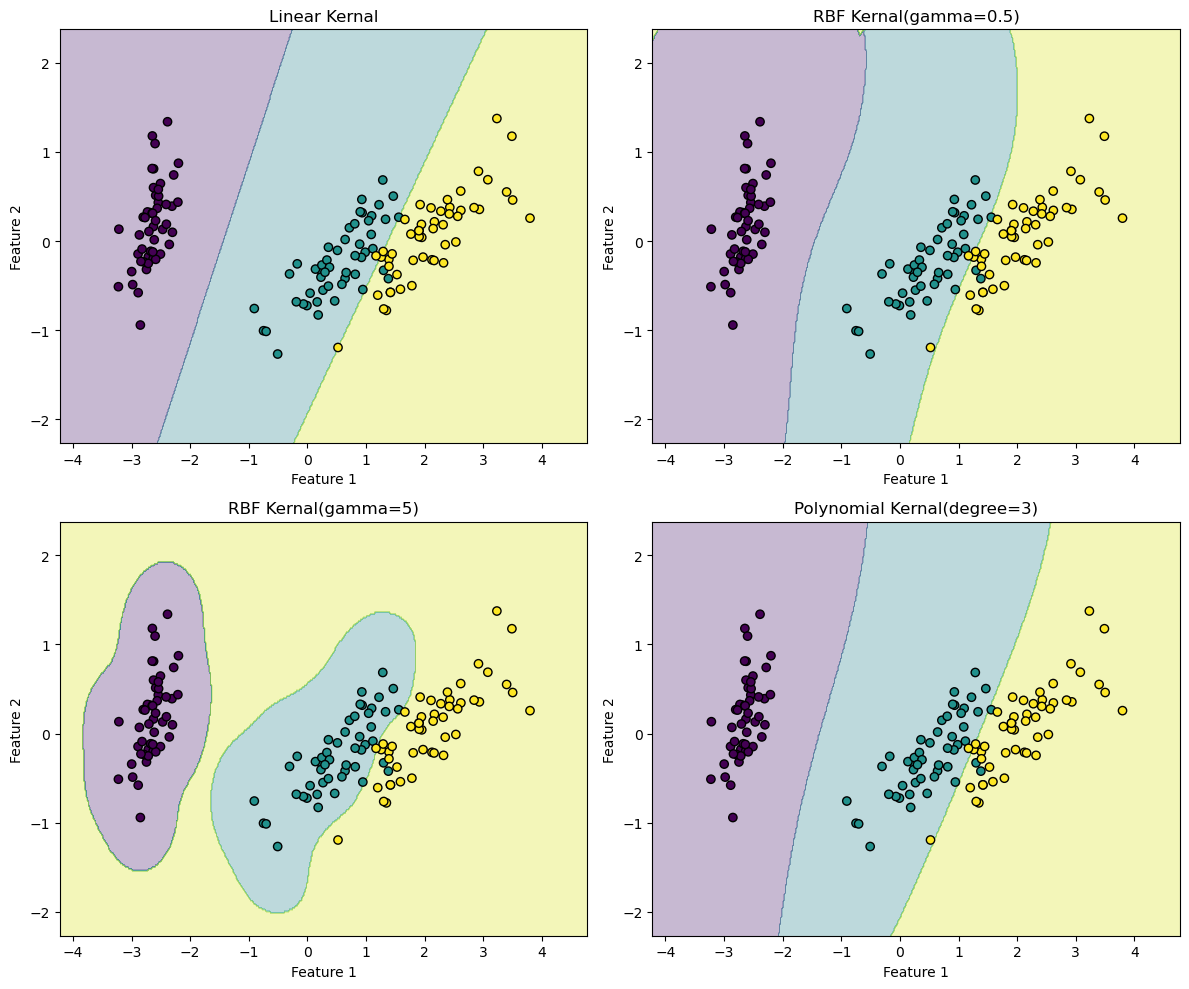

In [48]:
plt.figure(figsize=(12,10))
for i,(title,model) in enumerate(models,1):
    model.fit(X_train,y_train)
    Z=model.predict(np.c_[xx.ravel(),yy.ravel()])
    Z=Z.reshape(xx.shape)
    plt.subplot(2,2,i)
    plt.contourf(xx,yy,Z,alpha=0.3)
    plt.scatter(X_pca[:,0],X_pca[:,1],c=y,edgecolors='k')
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()

In [49]:
print("Model Performance")
for title,model in models:
    model.fit(X_train,y_train)
    acc=model.score(X_test,y_test)
    print(f"{title}:{acc:.2f}")

Model Performance
Linear Kernal:0.97
RBF Kernal(gamma=0.5):1.00
RBF Kernal(gamma=5):1.00
Polynomial Kernal(degree=3):1.00
